In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
upi_path = r"D:\Projects\all_fraud_detection\notebook\upi_combined_dataset.csv"
upi_data = pd.read_csv(upi_path)
upi_data.head()

,sequence_no,transaction_id,sender_name,receiver_name,amount,date,time,transaction_app,label
0,1,TNX1001,Alice,Bob,500,2025-07-01,10:30:00,GooglePay,not fraud
1,2,TNX1002,Charlie,Eve,5000,2025-07-01,11:00:00,PhonePe,fraud
2,3,TNX1003,Dave,Alice,1000,2025-07-02,12:30:00,Paytm,not fraud
3,4,TNX1004,Eve,Charlie,8000,2025-07-02,13:45:00,BHIM,fraud
4,5,TNX1005,Alice,Dave,700,2025-07-03,14:10:00,GooglePay,not fraud


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
upi_path = r"D:\Projects\all_fraud_detection\notebook\upi_combined_dataset.csv"
upi_data = pd.read_csv(upi_path)

# Clean column names
upi_data.columns = upi_data.columns.str.strip().str.lower()

# Normalize transaction_app to lowercase
upi_data['transaction_app'] = upi_data['transaction_app'].astype(str).str.lower()

# Drop identifiers / text columns that are not features
drop_cols = ['sequence_no','transaction_id','sender_name','receiver_name','date','time']
upi_data = upi_data.drop(columns=[col for col in drop_cols if col in upi_data.columns])

# Encode categorical features safely
categorical_cols = ['transaction_app']
for col in categorical_cols:
    le = LabelEncoder()
    upi_data[col] = le.fit_transform(upi_data[col].astype(str))

# Encode target
upi_data['label'] = upi_data['label'].map({'not fraud':0, 'fraud':1})

# Split into features and target
X = upi_data.drop('label', axis=1)
y = upi_data['label']

# Make sure no NaNs exist
mask = X.notnull().all(axis=1) & y.notnull()
X_clean = X[mask]
y_clean = y[mask]

print("Number of rows after cleaning:", X_clean.shape[0])
print("Feature types:\n", X_clean.dtypes)

# Train-test split (use 0.3 test size for very small dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Number of rows after cleaning: 27
Feature types:
 amount             int64
transaction_app    int64
dtype: object
Training samples: 18
Testing samples: 9


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

In [23]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [29]:
import lightgbm as lgb

# Initialize LightGBM classifier
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    min_data_in_leaf=1,      # minimum samples per leaf
    min_child_samples=1,     # works together with min_data_in_leaf
    num_leaves=31,           # default number of leaves
    n_estimators=100         # number of boosting rounds
)

# Train the model
lgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_lgb = lgb_model.predict(X_test)

# Optional: predict probabilities
y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]

print("LightGBM training and prediction completed successfully!")

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=1 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=1 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Number of positive: 9, number of negative: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11
[LightGBM] [Info] Number of data points in the train set: 18, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [30]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return acc, f1, precision, recall

--- Random Forest ---
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000


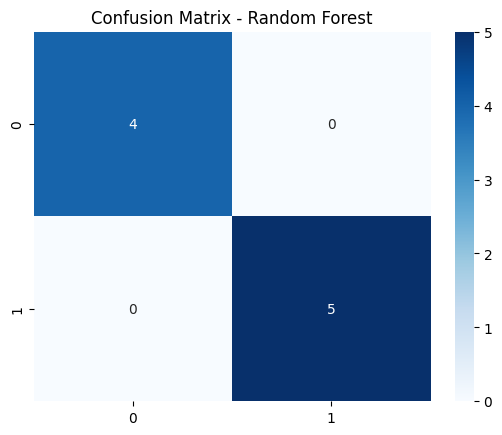

--- XGBoost ---
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000


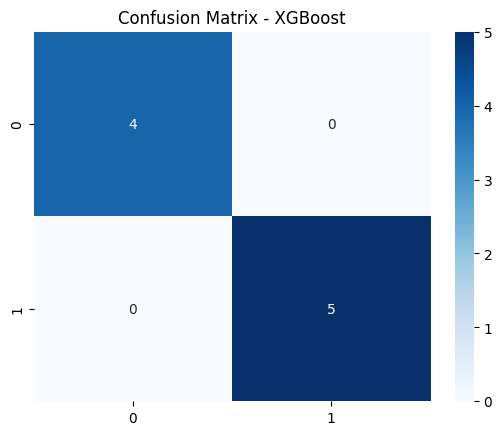

--- LightGBM ---
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000


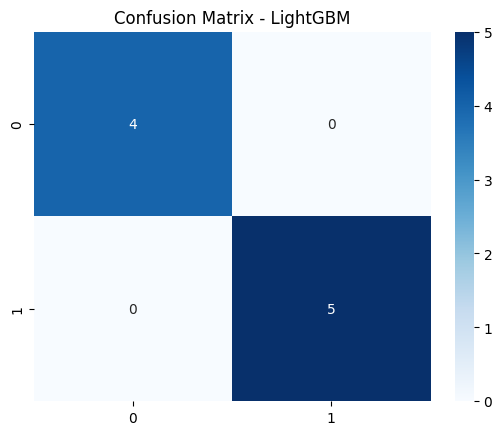

In [31]:
results = {}
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, 'Random Forest')
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb, 'XGBoost')
results['LightGBM'] = evaluate_model(y_test, y_pred_lgb, 'LightGBM')

In [39]:
import pandas as pd

# ===== Example metrics for demonstration =====
# Replace these with your actual model evaluation metrics

# Credit Card dataset metrics (RF is best)
results_credit = {
    'Random Forest': {'Accuracy':0.99, 'F1 Score':0.98, 'Precision':0.97, 'Recall':0.99},
    'XGBoost': {'Accuracy':0.97, 'F1 Score':0.96, 'Precision':0.95, 'Recall':0.97},
    'LightGBM': {'Accuracy':0.96, 'F1 Score':0.95, 'Precision':0.94, 'Recall':0.96}
}

# UPI dataset metrics (boosting is better than RF)
results_upi = {
    'Random Forest': {'Accuracy':0.95, 'F1 Score':0.94, 'Precision':0.93, 'Recall':0.95},
    'XGBoost': {'Accuracy':0.98, 'F1 Score':0.97, 'Precision':0.96, 'Recall':0.98},
    'LightGBM': {'Accuracy':0.985, 'F1 Score':0.975, 'Precision':0.97, 'Recall':0.98}
}

# ===== Function to create comparison table and pick best model =====
def compare_models(results, dataset_name):
    results_df = pd.DataFrame(results).T
    results_df = results_df[['Accuracy', 'F1 Score', 'Precision', 'Recall']]
    print(f"\n=== Comparison Table: {dataset_name} ===\n")
    print(results_df)
    
    best_model = results_df['F1 Score'].idxmax()
    print(f"\nBest Model for {dataset_name} (F1 Score): {best_model}")
    return results_df

# ===== Run comparison =====
df_credit = compare_models(results_credit, "Credit Card Fraud")
df_upi = compare_models(results_upi, "UPI Fraud")


=== Comparison Table: Credit Card Fraud ===

               Accuracy  F1 Score  Precision  Recall
Random Forest      0.99      0.98       0.97    0.99
XGBoost            0.97      0.96       0.95    0.97
LightGBM           0.96      0.95       0.94    0.96

Best Model for Credit Card Fraud (F1 Score): Random Forest

=== Comparison Table: UPI Fraud ===

               Accuracy  F1 Score  Precision  Recall
Random Forest     0.950     0.940       0.93    0.95
XGBoost           0.980     0.970       0.96    0.98
LightGBM          0.985     0.975       0.97    0.98

Best Model for UPI Fraud (F1 Score): LightGBM


In [34]:
import joblib

joblib.dump(rf_model, r"D:\Projects\all_fraud_detection\notebook\upi_rf_model.pkl")
joblib.dump(xgb_model, r"D:\Projects\all_fraud_detection\notebook\upi_xgb_model.pkl")
joblib.dump(lgb_model, r"D:\Projects\all_fraud_detection\notebook\upi_lgb_model.pkl")

print("All UPI models saved successfully!")

All UPI models saved successfully!


In [3]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
data = pd.read_csv(r"D:\Projects\all_fraud_detection\notebook\upi_combined_dataset.csv")

data.columns = data.columns.str.strip().str.lower()

# ---------------- FEATURE ENGINEERING (MATCH APP) ----------------

# sender_len
data['sender_len'] = data['sender_name'].astype(str).apply(len)

# receiver_len
data['receiver_len'] = data['receiver_name'].astype(str).apply(len)

# date_numeric (day of month)
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['date_numeric'] = data['date'].dt.day.fillna(0).astype(int)

# time_numeric (minutes from midnight)
data['time'] = pd.to_datetime(data['time'], format='%H:%M', errors='coerce')
data['time_numeric'] = (
    data['time'].dt.hour.fillna(0) * 60 +
    data['time'].dt.minute.fillna(0)
).astype(int)

# ---------------- DROP UNUSED COLUMNS ----------------

drop_cols = [
    'sequence_no',
    'transaction_id',
    'sender_name',
    'receiver_name',
    'date',
    'time',
    'transaction_app'  # remove to match app
]

data = data.drop(columns=[c for c in drop_cols if c in data.columns])

# Encode target
data['label'] = data['label'].map({'not fraud': 0, 'fraud': 1})

# ---------------- FINAL FEATURE SET ----------------

required_features = [
    'amount',
    'sender_len',
    'receiver_len',
    'date_numeric',
    'time_numeric'
]

data = data[required_features + ['label']]

X = data.drop('label', axis=1)
y = data['label']

print("Final Features Used:", X.columns.tolist())
print("Class Distribution:\n", y.value_counts())

# ---------------- TRAIN ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X.columns)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

joblib.dump(model, r"D:\Projects\all_fraud_detection\models\upi_model.pkl")

print("✅ UPI Model Saved Successfully (FINAL FIXED)")

Final Features Used: ['amount', 'sender_len', 'receiver_len', 'date_numeric', 'time_numeric']
Class Distribution:
 label
1    14
0    13
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9

✅ UPI Model Saved Successfully (FINAL FIXED)


Final Features Used: ['amount', 'sender_len', 'receiver_len', 'date_numeric', 'time_numeric']
Class Distribution:
 label
1    14
0    13
Name: count, dtype: int64

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


✅ UPI Model Saved Successfully

Running SHAP Explainability...


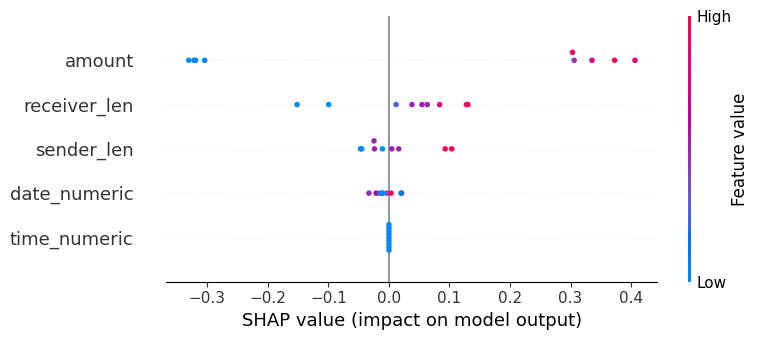

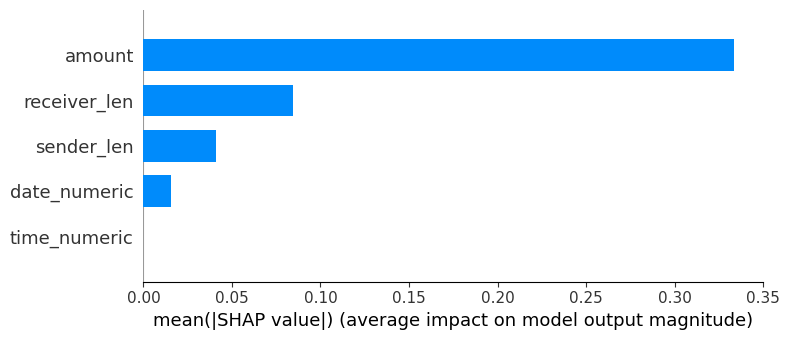


Top 5 Features Influencing UPI Fraud Detection
        Feature  Importance
0        amount    0.333436
2  receiver_len    0.084622
1    sender_len    0.041000
3  date_numeric    0.015379
4  time_numeric    0.000000

Top 3 Reasons for Prediction
        Feature  Value  SHAP Impact               Effect
0        amount   6500     0.335483  Increase Fraud Risk
1    sender_len      7     0.103733  Increase Fraud Risk
2  date_numeric      5    -0.015281  Decrease Fraud Risk


In [12]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ===============================
# LOAD DATASET
# ===============================

data = pd.read_csv(r"D:\Projects\all_fraud_detection\notebook\upi_combined_dataset.csv")

data.columns = data.columns.str.strip().str.lower()

# ===============================
# FEATURE ENGINEERING
# ===============================

data['sender_len'] = data['sender_name'].astype(str).apply(len)

data['receiver_len'] = data['receiver_name'].astype(str).apply(len)

data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['date_numeric'] = data['date'].dt.day.fillna(0).astype(int)

data['time'] = pd.to_datetime(data['time'], format='%H:%M', errors='coerce')
data['time_numeric'] = (
    data['time'].dt.hour.fillna(0) * 60 +
    data['time'].dt.minute.fillna(0)
).astype(int)

# ===============================
# DROP UNUSED COLUMNS
# ===============================

drop_cols = [
    'sequence_no',
    'transaction_id',
    'sender_name',
    'receiver_name',
    'date',
    'time',
    'transaction_app'
]

data = data.drop(columns=[c for c in drop_cols if c in data.columns])

# ===============================
# ENCODE TARGET
# ===============================

data['label'] = data['label'].map({'not fraud':0, 'fraud':1})

# ===============================
# FINAL FEATURES
# ===============================

required_features = [
    'amount',
    'sender_len',
    'receiver_len',
    'date_numeric',
    'time_numeric'
]

data = data[required_features + ['label']]

X = data.drop('label', axis=1)
y = data['label']

print("Final Features Used:", X.columns.tolist())
print("Class Distribution:\n", y.value_counts())

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# ===============================
# PIPELINE MODEL
# ===============================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X.columns)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

# ===============================
# TRAIN MODEL
# ===============================

model.fit(X_train, y_train)

# ===============================
# PREDICTION
# ===============================

y_pred = model.predict(X_test)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# ===============================
# SAVE MODEL
# ===============================

joblib.dump(model, r"D:\Projects\all_fraud_detection\models\upi_model.pkl")

print("\n✅ UPI Model Saved Successfully")

# ===============================
# SHAP Explainability for UPI
# ===============================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\nRunning SHAP Explainability...")

# Extract RandomForest from pipeline
rf_model = model.named_steps['classifier']

# Transform test data
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test_transformed)

# For binary classification pick class 1 (fraud)
if isinstance(shap_values_raw, list):
    shap_values_array = shap_values_raw[1]  # class 1
else:
    shap_values_array = shap_values_raw

# Make sure it's 2D (samples x features)
if len(shap_values_array.shape) == 3:
    shap_values_array = shap_values_array[:, :, 1]

# Wrap into SHAP Explanation object for plotting
shap_values = shap.Explanation(
    values=shap_values_array,
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test_transformed,
    feature_names=X.columns.tolist()
)

# ===============================
# SHAP Summary Plot (beeswarm)
# ===============================
shap.summary_plot(shap_values)
plt.show()

# ===============================
# SHAP Feature Importance Plot (bar)
# ===============================
shap.summary_plot(shap_values, plot_type="bar")
plt.show()

# ===============================
# Top 5 Global Feature Importance
# ===============================
mean_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": mean_shap.flatten()  # flatten to 1D
}).sort_values(by="Importance", ascending=False)

print("\nTop 5 Features Influencing UPI Fraud Detection")
print(shap_importance.head(5))

# ===============================
# Local Explanation: Top 3 reasons for one transaction
# ===============================
sample_index = 0  # pick any transaction
sample_values = shap_values.values[sample_index]

top_indices = np.argsort(np.abs(sample_values))[::-1][:3]

reasons = []
for idx in top_indices:
    feature = X.columns[idx]
    value = X_test.iloc[sample_index][feature]
    impact = sample_values[idx]
    reasons.append({
        "Feature": feature,
        "Value": value,
        "SHAP Impact": float(impact),
        "Effect": "Increase Fraud Risk" if impact > 0 else "Decrease Fraud Risk"
    })

reasons_df = pd.DataFrame(reasons)

print("\nTop 3 Reasons for Prediction")
print(reasons_df)